In [45]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
import seaborn as sb
import seaborn.objects as so

nCells = {"LDC-S": 1030301, "LDC-M": 8120601, "Wind": 6517376}
cases = {"LDC-S": "Lid-Driven-Cavity S", "LDC-M": "Lid-Driven-Cavity M", "Wind": "WindsorBody"}

all = pd.read_csv("results/results_new.csv", skip_blank_lines=True)
normd = []
for ms, case in zip(all["time_mean_ms"], all["case_short"]):
    normd.append(ms*1000000 / nCells[case])
all["time_mean_ns_normed"] = normd
df = all[all["cpu"]]
gpu_df = all[~all["cpu"]]
filtered = df[~df["variant"].str.contains("Only")]
gpufiltered = gpu_df[~gpu_df["variant"].str.contains("Only")]
sorted_variants = sorted(df["variant"].unique())
sorted_variants_filtered = sorted(filtered["variant"].unique())

In [15]:
gpu_df

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,cpu,gpu,time_mean_ns_normed
117,24.046656,22.703634,2.233788,0.0,LDC-M,LDC-M,faceBased,DivOnlyPrecalculatedWeightsUpwind,julia,False,True,2.961192
118,25.097364,23.690865,2.349198,0.0,LDC-M,LDC-M,faceBased,PrecalculatedWeightsUpwind,julia,False,True,3.090580
119,25.211113,23.683254,2.580716,0.0,LDC-M,LDC-M,faceBased,PrecalculatedWeightsCDF,julia,False,True,3.104587
120,23.108385,21.774702,2.228814,0.0,LDC-M,LDC-M,faceBased,DivOnlyPrecalculatedWeightsCDF,julia,False,True,2.845650
121,2.707762,2.721784,0.000000,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,False,True,2.628127
...,...,...,...,...,...,...,...,...,...,...,...,...
173,1.963723,1.950337,0.000000,0.0,LDC-M,LDC-M,batchedFace,DynamicUpwind,julia,False,True,0.241820
174,1.758039,1.481168,0.216896,0.0,LDC-M,LDC-M,batchedFace,DivOnlyPrecalculatedWeightsUpwind,julia,False,True,0.216491
175,2.235661,1.917953,0.228937,0.0,LDC-M,LDC-M,batchedFace,PrecalculatedWeightsUpwind,julia,False,True,0.275307
176,2.209553,1.918242,0.245584,0.0,LDC-M,LDC-M,batchedFace,PrecalculatedWeightsCDF,julia,False,True,0.272092


In [2]:
def float_to_power10(x):
    s = f"{x:.6e}"          # scientific notation string
    mantissa, exp = s.split('e')
    if round(float(mantissa), 1) == 1.0:
        return fr"$10^{int(exp)}$"
    else:
        return fr"${round(float(mantissa), 1)}10^{int(exp)}$"
def add_yticks_suffix(ax, suffix, toExp=True, doRound=True):
    ticks = ax.get_yticks()
    suffixed = [""]*len(ticks)
    for i in range(len(ticks)):
        x = ticks[i]
        if toExp:
            x = float_to_power10(x)
        else:
            if doRound:
                x = str(int(x))
            else:
                x = str(round(x, 2))

        suffixed[i] = x + suffix

    ax.yaxis.set_ticklabels(suffixed)

In [3]:
float_to_power10(1000)

'$10^3$'

In [4]:
df

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,cpu,gpu,time_mean_ns_normed
0,99.812780,101.696720,4.098518,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,True,False,96.877301
1,105.409200,103.057816,8.083513,0.0,LDC-S,LDC-S,faceBased,PrecalculatedWeightsUpwind,julia,True,False,102.309131
2,102.978250,101.667290,3.029836,0.0,LDC-S,LDC-S,faceBased,DivOnlyHardCodedUpwind,julia,True,False,99.949675
3,42.974182,33.386826,9.064015,0.0,LDC-S,LDC-S,faceBased,LaplaceOnly,julia,True,False,41.710318
4,101.436844,96.292114,4.461367,0.0,LDC-S,LDC-S,faceBased,DynamicCDF,julia,True,False,98.453601
...,...,...,...,...,...,...,...,...,...,...,...,...
112,1671.027600,1670.865800,0.000000,0.0,LDC-M,LDC-M,cellBased,DivOnlyPrecalculatedWeightsUpwind,julia,True,False,205.776346
113,1549.805000,1538.788800,14.032230,0.0,LDC-M,LDC-M,cellBased,DivOnlyDynamicUpwind,julia,True,False,190.848559
114,1722.432000,1720.603300,0.000000,0.0,LDC-M,LDC-M,cellBased,PrecalculatedWeightsCDF,julia,True,False,212.106468
115,1565.566900,1552.270400,13.411845,0.0,LDC-M,LDC-M,cellBased,DynamicUpwind,julia,True,False,192.789536


In [5]:
def draw_boxplot(data, x, y, save=False, annotate=False, useLog=False, ylabel="", xlabel="",ax=None):
    yl = ylabel or y
    xl = xlabel or x
    if ax:
        plot = sb.boxplot(data=data, ax=ax, x=x, y=y, log_scale=useLog, gap=.1).set(
            ylabel=yl, xlabel=xl
        )
    else:
        plot = sb.boxplot(data=data, x=x, y=y, log_scale=useLog, gap=.1).set(
            ylabel=yl, xlabel=xl
        )
    if annotate:
        minvals = data.loc[data.groupby("strategy")["time_mean_ms"].idxmin()]
        mapping = {"faceBased": 0, "globalFaceBased": 1, "cellBased": 2}
        for i, row in minvals.iterrows():
            plot.annotate(row["variant"],
                    xy=(mapping[row["strategy"]], row[y]),
                    fontsize=12)
    if save:
        plt.savefig(f"figures/{save}.svg")

/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)


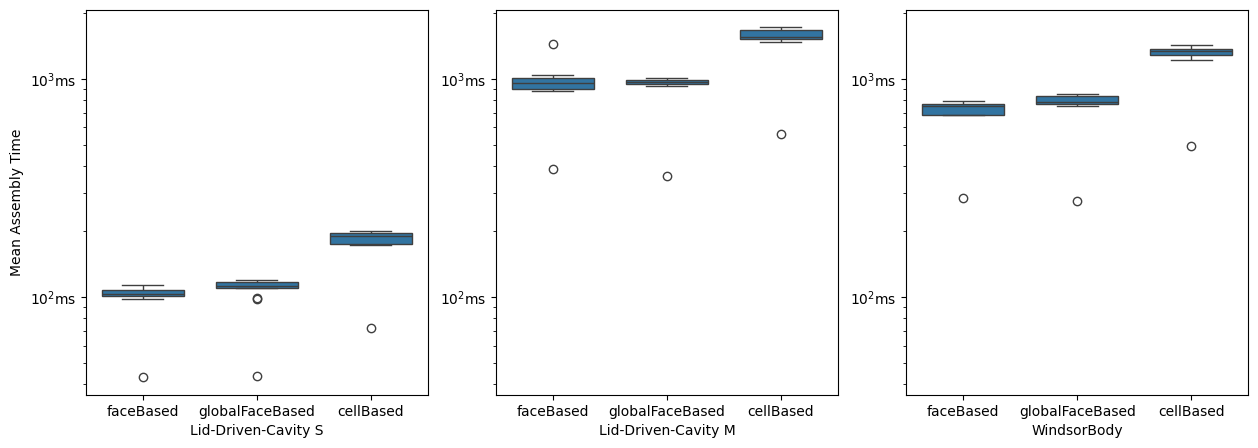

In [6]:
fig, axes = plt.subplots(1,3, figsize=(15, 5), sharey=True)
for i, ax in enumerate(axes.flat):
    case_df = df[df["case_short"] == list(cases.keys())[i]]
    draw_boxplot(case_df, ax=ax, x="strategy", y="time_mean_ms", save=False, annotate=False, xlabel=list(cases.values())[i], useLog=True, ylabel="Mean Assembly Time")
    ax.yaxis.set_tick_params(labelleft=True)
    add_yticks_suffix(ax=ax, suffix="ms")

/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)


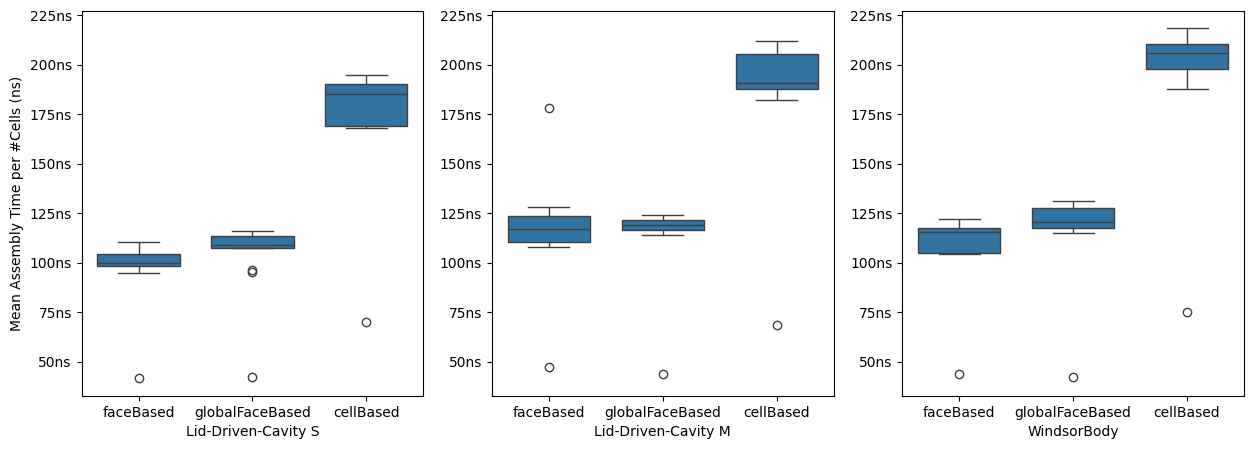

In [7]:
fig, axes = plt.subplots(1,3, figsize=(15, 5), sharey=True)
for i, ax in enumerate(axes.flat):
    case_df = df[df["case_short"] == list(cases.keys())[i]]
    draw_boxplot(case_df, ax=ax, x="strategy", y="time_mean_ns_normed", save=False, annotate=False, xlabel=list(cases.values())[i], ylabel="Mean Assembly Time per #Cells (ns)")
    ax.yaxis.set_tick_params(labelleft=True)
    add_yticks_suffix(ax, "ns", toExp=False)

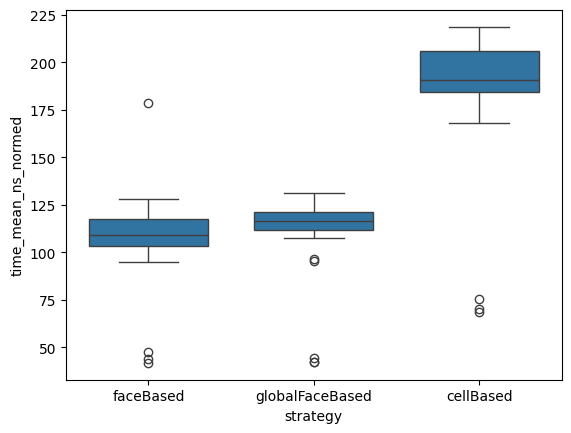

In [8]:
draw_boxplot(df, x="strategy", y="time_mean_ns_normed", save=False, annotate=False)

In [9]:
filtered

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,cpu,gpu,time_mean_ns_normed
1,105.409200,103.057816,8.083513,0.0,LDC-S,LDC-S,faceBased,PrecalculatedWeightsUpwind,julia,True,False,102.309131
4,101.436844,96.292114,4.461367,0.0,LDC-S,LDC-S,faceBased,DynamicCDF,julia,True,False,98.453601
7,113.694130,111.922990,4.249827,0.0,LDC-S,LDC-S,faceBased,HardCodedUpwind,julia,True,False,110.350402
10,102.538000,96.493910,4.994685,0.0,LDC-S,LDC-S,faceBased,PrecalculatedWeightsCDF,julia,True,False,99.522373
11,102.518670,97.210900,5.056023,0.0,LDC-S,LDC-S,faceBased,HardCodedCDF,julia,True,False,99.503611
12,113.017190,107.462036,4.427753,0.0,LDC-S,LDC-S,faceBased,DynamicUpwind,julia,True,False,109.693371
14,119.426460,114.799050,4.169004,0.0,LDC-S,LDC-S,globalFaceBased,PrecalculatedWeightsUpwind,julia,True,False,115.914145
17,114.270920,108.676490,3.471211,0.0,LDC-S,LDC-S,globalFaceBased,DynamicCDF,julia,True,False,110.910229
20,116.835890,111.536224,4.088986,0.0,LDC-S,LDC-S,globalFaceBased,HardCodedUpwind,julia,True,False,113.399764
23,119.829960,115.569180,4.159248,0.0,LDC-S,LDC-S,globalFaceBased,PrecalculatedWeightsCDF,julia,True,False,116.305779


/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)


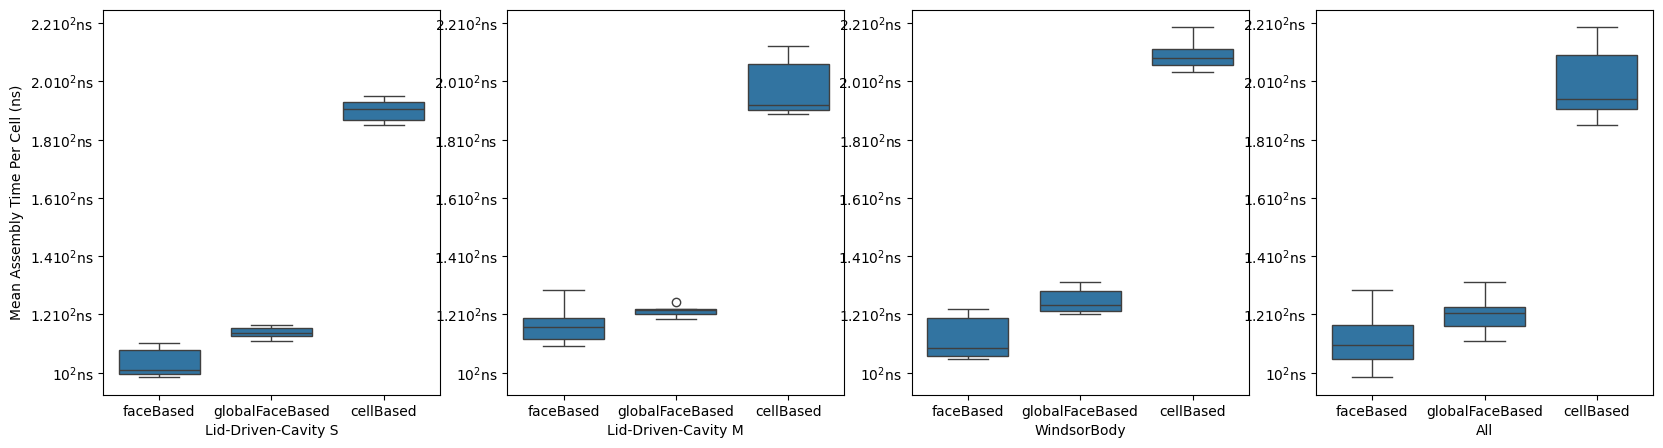

In [10]:
fig, axes = plt.subplots(1,4, figsize=(20, 5), sharey=True)
for i, ax in enumerate(axes.flat[0:3]):
    case_df = filtered[filtered["case_short"] == list(cases.keys())[i]]
    draw_boxplot(case_df, ax=ax, x="strategy", y="time_mean_ns_normed", save=False, annotate=False, xlabel=list(cases.values())[i], ylabel="Mean Assembly Time Per Cell (ns)")
    ax.yaxis.set_tick_params(labelleft=True)
draw_boxplot(filtered, ax=axes.flat[3], x="strategy", y="time_mean_ns_normed", save=False, annotate=False, xlabel="All", ylabel="Mean Assembly Time Per Cell (ns)")
axes.flat[3].yaxis.set_tick_params(labelleft=True)
add_yticks_suffix(axes.flat[1], "ns")


time_mean_ms Mean Assembly Time (ms)
time_mean_ns_normed Mean Assembly Time Per Cell (ms)


/tmp/ipykernel_146404/2104469259.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),
/tmp/ipykernel_146404/2104469259.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


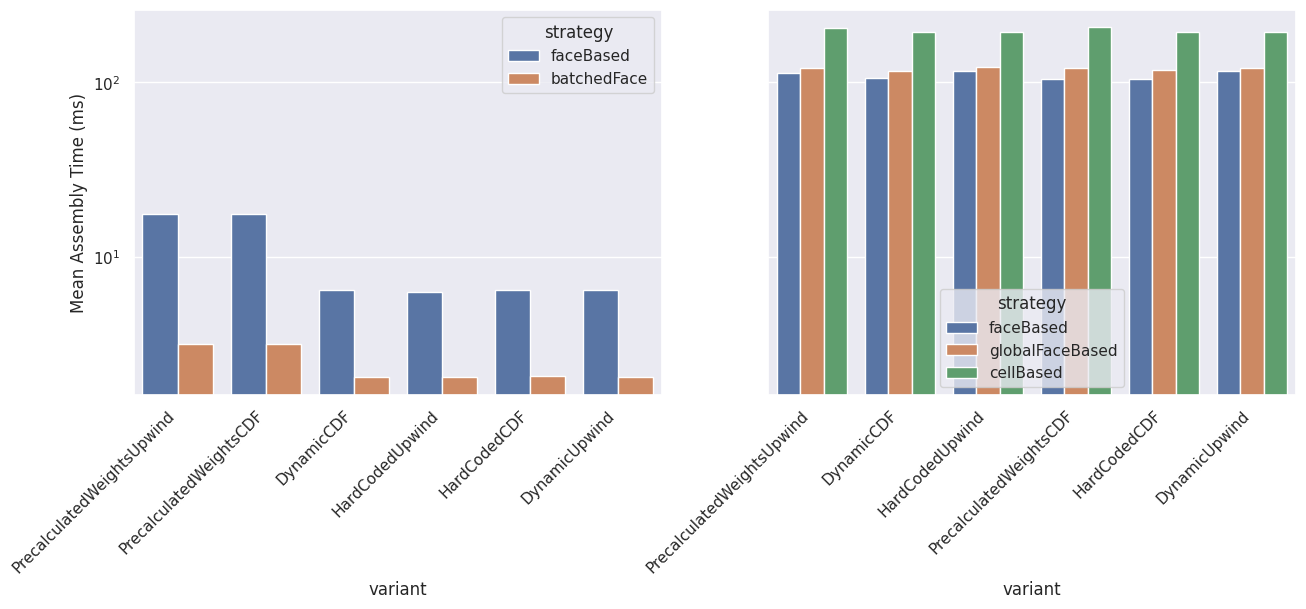

In [46]:
fig, axes = plt.subplots(1,2, figsize=(15, 5), sharey=True)

for i, ax in enumerate(axes.flat):
    y = "time_mean_ms" if i == 0 else "time_mean_ns_normed"
    yl = "Mean Assembly Time (ms)" if i == 0 else "Mean Assembly Time Per Cell (ms)"
    print(y,yl)
    if i == 1:
        p =  sb.barplot(filtered, ax=ax, x="variant", y=y, hue="strategy", errorbar=None)
    else :
        p =  sb.barplot(gpufiltered, ax=ax, x="variant", y=y, hue="strategy", errorbar=None)
    p.set_yscale("log")
    p.set(
        ylabel=yl,
    )

    p.set_xticklabels(p.get_xticklabels(), 
                            rotation=45, 
                            horizontalalignment='right'
    )


<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>


/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/196270303.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


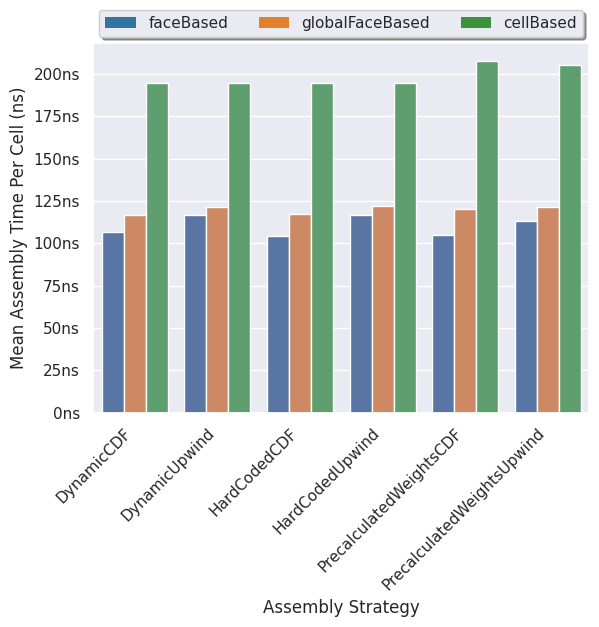

In [12]:
sb.set_theme()
fig, ax= plt.subplots()
y = "time_mean_ns_normed"
yl = "Mean Assembly Time Per Cell (ns)"
p =  sb.barplot(filtered,ax=ax ,x="variant", y=y, hue="strategy", legend="brief", order=sorted_variants_filtered, errorbar=None)
# p.set_yscale("log")
p.set(
    ylabel=yl,
    xlabel="Assembly Strategy"

)
add_yticks_suffix(ax,"ns",False, True)

p.set_xticklabels(p.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
)
labels = ax.get_legend_handles_labels()[1]
ax.legend().remove()

for t, new_label in zip(ax.legend().texts, labels):
    print(type(t))
    t.set_text(new_label)
handles, labels = axes[0].get_legend_handles_labels()
plt.legend(handles, labels, loc="upper center", bbox_to_anchor = (0.5,1.11),ncol=6, fancybox=True, shadow=True)


In [13]:
gpu_df

,time_mean_ms,time_median_ms,gc_time_mean_ms,gc_time_median_ms,case_short,case_long,strategy,variant,language,cpu,gpu,time_mean_ns_normed
117,24.046656,22.703634,2.233788,0.0,LDC-M,LDC-M,faceBased,DivOnlyPrecalculatedWeightsUpwind,julia,False,True,2.961192
118,25.097364,23.690865,2.349198,0.0,LDC-M,LDC-M,faceBased,PrecalculatedWeightsUpwind,julia,False,True,3.090580
119,25.211113,23.683254,2.580716,0.0,LDC-M,LDC-M,faceBased,PrecalculatedWeightsCDF,julia,False,True,3.104587
120,23.108385,21.774702,2.228814,0.0,LDC-M,LDC-M,faceBased,DivOnlyPrecalculatedWeightsCDF,julia,False,True,2.845650
121,2.707762,2.721784,0.000000,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,False,True,2.628127
...,...,...,...,...,...,...,...,...,...,...,...,...
173,1.963723,1.950337,0.000000,0.0,LDC-M,LDC-M,batchedFace,DynamicUpwind,julia,False,True,0.241820
174,1.758039,1.481168,0.216896,0.0,LDC-M,LDC-M,batchedFace,DivOnlyPrecalculatedWeightsUpwind,julia,False,True,0.216491
175,2.235661,1.917953,0.228937,0.0,LDC-M,LDC-M,batchedFace,PrecalculatedWeightsUpwind,julia,False,True,0.275307
176,2.209553,1.918242,0.245584,0.0,LDC-M,LDC-M,batchedFace,PrecalculatedWeightsCDF,julia,False,True,0.272092


<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>


/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/3906324338.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


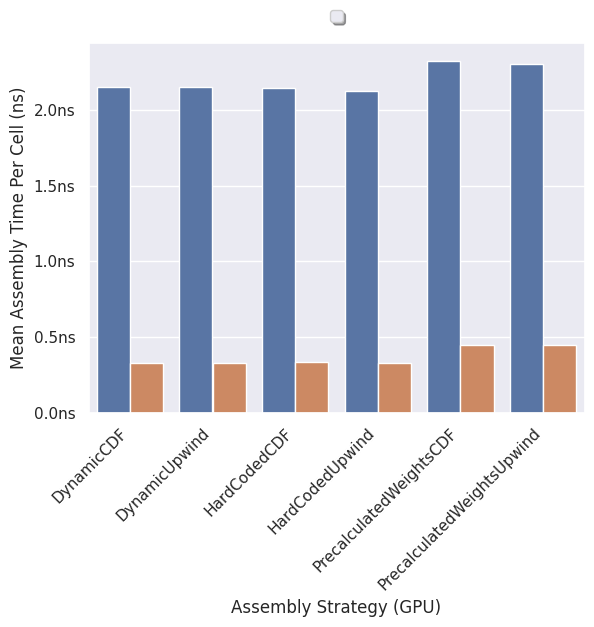

In [ ]:
sb.set_theme()
fig, ax= plt.subplots()
y = "time_mean_ns_normed"
yl = "Mean Assembly Time Per Cell (ns)"
p =  sb.barplot(gpu_df,ax=ax ,x="variant", y=y, hue="strategy", legend="brief", order=sorted_variants_filtered, errorbar=None)
# p.set_yscale("log")
p.set(
    ylabel=yl,
    xlabel="Assembly Strategy (GPU)"
)
# ax.set_ylim(2, 3.5)
add_yticks_suffix(ax,"ns",False, False)
p.set_xticklabels(p.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
)
labels = ax.get_legend_handles_labels()[1]
ax.legend().remove()

for t, new_label in zip(ax.legend().texts, labels):
    print(type(t))
    t.set_text(new_label)
handles, labels = axes[0].get_legend_handles_labels()
plt.legend(handles, labels, loc="upper center", bbox_to_anchor = (0.5,1.11),ncol=6, fancybox=True, shadow=True)


IndexError: index 3 is out of bounds for size 3

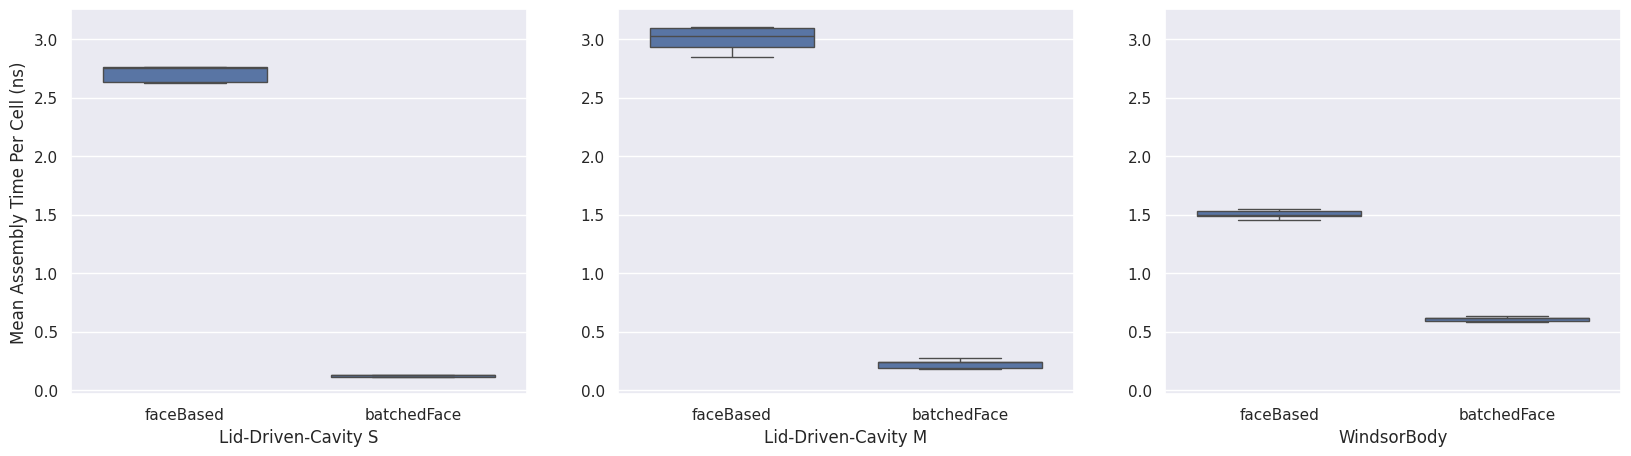

In [30]:
fig, axes = plt.subplots(1,3, figsize=(20, 5), sharey=True)
for i, ax in enumerate(axes.flat[0:3]):
    case_df = gpu_df[gpu_df["case_short"] == list(cases.keys())[i]]
    draw_boxplot(case_df, ax=ax, x="strategy", y="time_mean_ns_normed", save=False, annotate=False, xlabel=list(cases.values())[i], ylabel="Mean Assembly Time Per Cell (ns)")
    ax.yaxis.set_tick_params(labelleft=True)
    
draw_boxplot(gpu_df, ax=axes.flat[3], x="strategy", y="time_mean_ns_normed", save=False, annotate=False, xlabel="All", ylabel="Mean Assembly Time Per Cell (ns)")
axes.flat[2].yaxis.set_tick_params(labelleft=True)
add_yticks_suffix(axes.flat[1], "ns")


<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>


/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/3441862672.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),
/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/3441862672.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


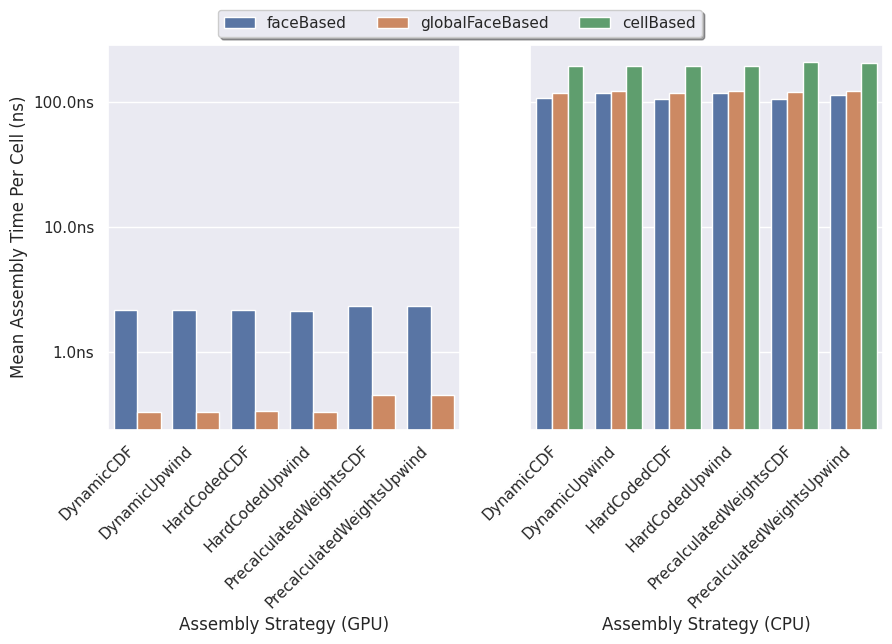

In [47]:
sb.set_theme()
fig, axes= plt.subplots(1,2, sharey=True, figsize=(10,5))
ax = axes.flat[0]
ax2 = axes.flat[1]
y = "time_mean_ns_normed"
yl = "Mean Assembly Time Per Cell (ns)"

p =  sb.barplot(gpufiltered,ax=ax ,x="variant", y=y, hue="strategy", legend="brief", order=sorted_variants_filtered, errorbar=None)
p.set_yscale("log")
p.set(
    ylabel=yl,
    xlabel="Assembly Strategy (GPU)"
)
add_yticks_suffix(ax,"ns",False, False)
p.set_xticklabels(p.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
)
labels = ax.get_legend_handles_labels()[1]
ax.legend().remove()


p =  sb.barplot(filtered,ax=ax2 ,x="variant", y=y, hue="strategy", legend="brief", order=sorted_variants_filtered, errorbar=None)
p.set(
    ylabel=yl,
    xlabel="Assembly Strategy (CPU)"
)
add_yticks_suffix(ax,"ns",False, False)
p.set_xticklabels(p.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
)
labels = ax.get_legend_handles_labels()[1]
ax.legend().remove()


for t, new_label in zip(ax2.legend().texts, labels):
    print(type(t))
    t.set_text(new_label)
handles, labels = axes[1].get_legend_handles_labels()
plt.legend(handles, labels, loc="upper center", bbox_to_anchor = (-0.2,1.11),ncol=6, fancybox=True, shadow=True)


<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>
<class 'matplotlib.text.Text'>


/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/1318545129.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),
/tmp/ipykernel_146404/2483392874.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(suffixed)
/tmp/ipykernel_146404/1318545129.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


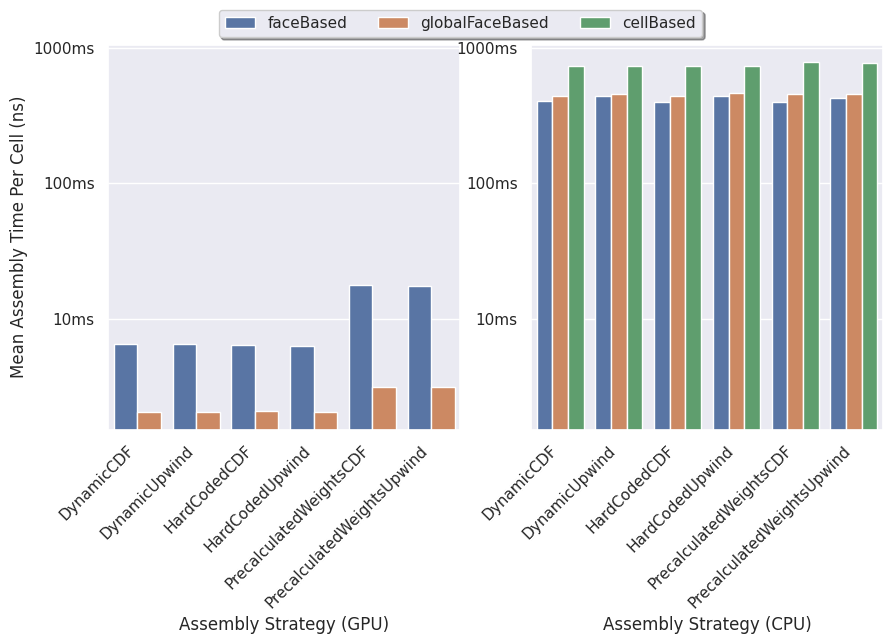

In [55]:
sb.set_theme()
fig, axes= plt.subplots(1,2, sharey=True, figsize=(10,5))
ax = axes.flat[0]
ax2 = axes.flat[1]
y = "time_mean_ms"
yl = "Mean Assembly Time Per Cell (ns)"

p =  sb.barplot(gpufiltered,ax=ax ,x="variant", y=y, hue="strategy", legend="brief", order=sorted_variants_filtered, errorbar=None)
p.set_yscale("log")
p.set(
    ylabel=yl,
    xlabel="Assembly Strategy (GPU)"
)
add_yticks_suffix(ax,"ms",False, False)
p.set_xticklabels(p.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
)
labels = ax.get_legend_handles_labels()[1]
ax.legend().remove()


p =  sb.barplot(filtered,ax=ax2 ,x="variant", y=y, hue="strategy", legend="brief", order=sorted_variants_filtered, errorbar=None)
p.set(
    ylabel=yl,
    xlabel="Assembly Strategy (CPU)"
)
add_yticks_suffix(ax2,"ms",False, True)
p.set_xticklabels(p.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
)

labels = ax2.get_legend_handles_labels()[1]
ax2.legend().remove()
ax2.yaxis.set_tick_params(labelleft=True)


for t, new_label in zip(ax2.legend().texts, labels):
    print(type(t))
    t.set_text(new_label)
handles, labels = axes[1].get_legend_handles_labels()
plt.legend(handles, labels, loc="upper center", bbox_to_anchor = (-0.2,1.11),ncol=6, fancybox=True, shadow=True)


In [60]:
speedup = []
speedup = df.merge(gpu_df, on="variant", suffixes=("_1", "_2"))
speedup["speedup"] = speedup["time_mean_ms_1"] / speedup["time_mean_ms_2"]
speedup


,time_mean_ms_1,time_median_ms_1,gc_time_mean_ms_1,gc_time_median_ms_1,case_short_1,case_long_1,strategy_1,variant,language_1,cpu_1,...,gc_time_mean_ms_2,gc_time_median_ms_2,case_short_2,case_long_2,strategy_2,language_2,cpu_2,gpu_2,time_mean_ns_normed_2,speedup
0,99.81278,101.69672,4.098518,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,True,...,0.0,0.0,LDC-S,LDC-S,faceBased,julia,False,True,2.628127,36.861732
1,99.81278,101.69672,4.098518,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,True,...,0.0,0.0,Wind,Wind,faceBased,julia,False,True,1.496013,10.237127
2,99.81278,101.69672,4.098518,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,True,...,0.0,0.0,LDC-S,LDC-S,batchedFace,julia,False,True,0.117194,826.638981
3,99.81278,101.69672,4.098518,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,True,...,0.0,0.0,Wind,Wind,batchedFace,julia,False,True,0.585878,26.140054
4,99.81278,101.69672,4.098518,0.0,LDC-S,LDC-S,faceBased,DivOnlyDynamicCDF,julia,True,...,0.0,0.0,LDC-M,LDC-M,batchedFace,julia,False,True,0.184126,66.754922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,1548.68100,1551.78160,12.534647,0.0,LDC-M,LDC-M,cellBased,HardCodedCDF,julia,True,...,0.0,0.0,LDC-S,LDC-S,faceBased,julia,False,True,2.761228,544.371745
545,1548.68100,1551.78160,12.534647,0.0,LDC-M,LDC-M,cellBased,HardCodedCDF,julia,True,...,0.0,0.0,Wind,Wind,faceBased,julia,False,True,1.531305,155.177042
546,1548.68100,1551.78160,12.534647,0.0,LDC-M,LDC-M,cellBased,HardCodedCDF,julia,True,...,0.0,0.0,LDC-S,LDC-S,batchedFace,julia,False,True,0.131071,11468.082949
547,1548.68100,1551.78160,12.534647,0.0,LDC-M,LDC-M,cellBased,HardCodedCDF,julia,True,...,0.0,0.0,Wind,Wind,batchedFace,julia,False,True,0.632835,375.490560


/tmp/ipykernel_146404/3264849100.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  p.set_xticklabels(p.get_xticklabels(),


[Text(0, 0, 'DynamicCDF'),
 Text(1, 0, 'DynamicUpwind'),
 Text(2, 0, 'HardCodedCDF'),
 Text(3, 0, 'HardCodedUpwind'),
 Text(4, 0, 'PrecalculatedWeightsCDF'),
 Text(5, 0, 'PrecalculatedWeightsUpwind')]

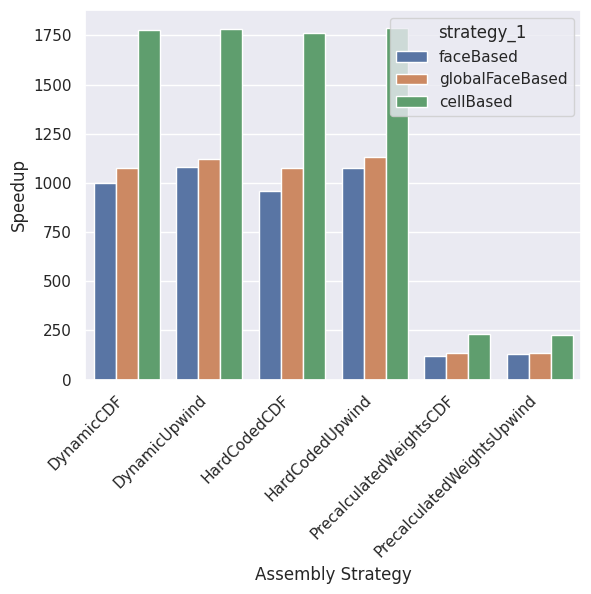

In [68]:
p = sb.barplot(speedup,x="variant", y="speedup", hue="strategy_1", legend="brief", order=sorted_variants_filtered, errorbar=None)
p.set(
    ylabel="Speedup",
    xlabel="Assembly Strategy"

)
p.set_xticklabels(p.get_xticklabels(), 
                        rotation=45, 
                        horizontalalignment='right'
)
